[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/10_pandas_sql/10_7_Exercises.ipynb)

# 10.7: Exercises

These exercises cover the full module: `df.query()`, SQLite setup, SELECT and WHERE, GROUP BY and HAVING, JOIN, and subqueries. All exercises use the Gapminder dataset split into the same `countries` and `measurements` tables used throughout the module.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")

countries = df[["country", "continent"]].drop_duplicates().reset_index(drop=True)
measurements = df[["country", "year", "lifeExp", "pop", "gdpPercap"]].copy()

conn = sqlite3.connect(":memory:")
countries.to_sql("countries", conn, index=False, if_exists="replace")
measurements.to_sql("measurements", conn, index=False, if_exists="replace")
df.to_sql("gapminder", conn, index=False, if_exists="replace")

print(f"Full dataset: {df.shape}")
print(f"countries table: {countries.shape}")
print(f"measurements table: {measurements.shape}")
df.head()

Full dataset: (1704, 6)
countries table: (142, 2)
measurements table: (1704, 5)


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


---
## Part 1: `df.query()`

### Exercise 1

Using `df.query()`, find all countries in Asia with a life expectancy above 72 in 2007. Return only the `country` and `lifeExp` columns, sorted by life expectancy descending.

In [2]:
# your code here

In [3]:
#@title Solution
(
    df.query("continent == 'Asia' and year == 2007 and lifeExp > 72")
    [["country", "lifeExp"]]
    .sort_values("lifeExp", ascending=False)
)

,country,lifeExp
803,Japan,82.603
671,"Hong Kong, China",82.208
767,Israel,80.745
1367,Singapore,79.972
851,"Korea, Rep.",78.623
1511,Taiwan,78.400
863,Kuwait,77.588
1163,Oman,75.640
95,Bahrain,75.635
1655,Vietnam,74.249


### Exercise 2

Compute the dataset-wide mean GDP per capita (across all countries and years). Then use `df.query()` with `@variable` injection to find all rows where `gdpPercap` is above that mean. How many rows is that, and what fraction of the total dataset does it represent?

In [4]:
# your code here

In [5]:
#@title Solution
mean_gdp = df["gdpPercap"].mean()
above_mean = df.query("gdpPercap > @mean_gdp")
print(f"Mean GDP per capita: ${mean_gdp:,.0f}")
print(f"Rows above mean: {len(above_mean)}")
print(f"Fraction: {len(above_mean) / len(df):.1%}")

Mean GDP per capita: $7,215
Rows above mean: 534
Fraction: 31.3%


### Exercise 3

Using `df.query()`, find all country-year rows where the life expectancy was below 40 OR the GDP per capita was above $40,000. Return `country`, `year`, `lifeExp`, and `gdpPercap`, sorted by `lifeExp` ascending.

In [6]:
# your code here

In [7]:
#@title Solution
(
    df.query("lifeExp < 40 or gdpPercap > 40000")
    [["country", "year", "lifeExp", "gdpPercap"]]
    .sort_values("lifeExp")
)

,country,year,lifeExp,gdpPercap
1292,Rwanda,1992,23.599,737.068595
0,Afghanistan,1952,28.801,779.445314
552,Gambia,1952,30.000,485.230659
36,Angola,1952,30.015,3520.610273
1344,Sierra Leone,1952,30.331,879.787736
...,...,...,...,...
1149,Norway,1997,78.320,41283.164330
755,Ireland,2007,78.885,40675.996350
1150,Norway,2002,79.050,44683.975250
1367,Singapore,2007,79.972,47143.179640


---
## Part 2: SELECT and WHERE

### Exercise 4

Write a SQL query that returns the 10 countries with the highest life expectancy in 2007. Return `country` and `lifeExp`, sorted descending.

In [8]:
# your code here

In [9]:
#@title Solution
pd.read_sql("""
    SELECT country, lifeExp
    FROM measurements
    WHERE year = 2007
    ORDER BY lifeExp DESC
    LIMIT 10
""", conn)

,country,lifeExp
0,Japan,82.603
1,"Hong Kong, China",82.208
2,Iceland,81.757
3,Switzerland,81.701
4,Australia,81.235
5,Spain,80.941
6,Sweden,80.884
7,Israel,80.745
8,France,80.657
9,Canada,80.653


### Exercise 5

Write a SQL query using `WHERE` and `IN` to return all rows from `measurements` where the year is 1952 or 2007. Return `country`, `year`, and `lifeExp`. How many rows does the result have?

In [10]:
# your code here

In [11]:
#@title Solution
result = pd.read_sql("""
    SELECT country, year, lifeExp
    FROM measurements
    WHERE year IN (1952, 2007)
    ORDER BY country, year
""", conn)
print(f"Rows: {len(result)}")
result.head()

Rows: 284


,country,year,lifeExp
0,Afghanistan,1952,28.801
1,Afghanistan,2007,43.828
2,Albania,1952,55.230
3,Albania,2007,76.423
4,Algeria,1952,43.077


### Exercise 6

Write a SQL query using `LIKE` to find all distinct country names that contain the word "New". Return each country name once, sorted alphabetically.

In [12]:
# your code here

In [13]:
#@title Solution
pd.read_sql("""
    SELECT DISTINCT country
    FROM measurements
    WHERE country LIKE '%New%'
    ORDER BY country
""", conn)

,country
0,New Zealand


---
## Part 3: GROUP BY and HAVING

### Exercise 7

Write a SQL `GROUP BY` query that returns the average life expectancy per continent across all years. Use a JOIN to bring in the continent column. Sort by average life expectancy descending and round to 1 decimal place.

In [14]:
# your code here

In [15]:
#@title Solution
pd.read_sql("""
    SELECT c.continent,
           ROUND(AVG(m.lifeExp), 1) AS avg_life
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    GROUP BY c.continent
    ORDER BY avg_life DESC
""", conn)

,continent,avg_life
0,Oceania,74.3
1,Europe,71.9
2,Americas,64.7
3,Asia,60.1
4,Africa,48.9


### Exercise 8

Write a SQL query that returns the number of distinct countries in each continent. Name the count column `n_countries`. Use `COUNT(DISTINCT ...)`. Sort by `n_countries` descending.

In [16]:
# your code here

In [17]:
#@title Solution
pd.read_sql("""
    SELECT c.continent,
           COUNT(DISTINCT m.country) AS n_countries
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    GROUP BY c.continent
    ORDER BY n_countries DESC
""", conn)

,continent,n_countries
0,Africa,52
1,Asia,33
2,Europe,30
3,Americas,25
4,Oceania,2


### Exercise 9

Write a SQL query using `HAVING` to find continents where the average GDP per capita in 2007 exceeded $15,000. Return the continent name, average GDP per capita (rounded to 0 decimal places), and the number of countries.

In [18]:
# your code here

In [19]:
#@title Solution
pd.read_sql("""
    SELECT c.continent,
           ROUND(AVG(m.gdpPercap), 0) AS avg_gdp,
           COUNT(DISTINCT m.country) AS n_countries
    FROM measurements AS m
    JOIN countries AS c ON m.country = c.country
    WHERE m.year = 2007
    GROUP BY c.continent
    HAVING AVG(m.gdpPercap) > 15000
    ORDER BY avg_gdp DESC
""", conn)

,continent,avg_gdp,n_countries
0,Oceania,29810.0,2
1,Europe,25054.0,30


---
## Part 4: JOIN

### Exercise 10

Write a SQL `INNER JOIN` query that combines the `countries` and `measurements` tables. Return `continent`, `year`, and mean life expectancy (rounded to 1 decimal place), grouped by continent and year, for years after 1990. Sort by continent and year. How many rows does the result have?

In [20]:
# your code here

In [21]:
#@title Solution
result = pd.read_sql("""
    SELECT c.continent,
           m.year,
           ROUND(AVG(m.lifeExp), 1) AS avg_life
    FROM measurements AS m
    INNER JOIN countries AS c ON m.country = c.country
    WHERE m.year > 1990
    GROUP BY c.continent, m.year
    ORDER BY c.continent, m.year
""", conn)
print(f"Rows: {len(result)}")
result

Rows: 20


,continent,year,avg_life
0,Africa,1992,53.6
1,Africa,1997,53.6
2,Africa,2002,53.3
3,Africa,2007,54.8
4,Americas,1992,69.6
5,Americas,1997,71.2
6,Americas,2002,72.4
7,Americas,2007,73.6
8,Asia,1992,66.5
9,Asia,1997,68.0


### Exercise 11

Add a fake country to the `countries` table (country="Wakanda", continent="Africa") using `pd.concat()`, then reload it into SQLite. Write a `LEFT JOIN` query that joins `countries` (left) to `measurements` (right) and filters to show only the rows where no measurements exist (that is, where the right-table columns are NULL). This demonstrates how LEFT JOIN can find unmatched records.

In [22]:
# your code here

In [23]:
#@title Solution
fake = pd.DataFrame([{"country": "Wakanda", "continent": "Africa"}])
countries_with_fake = pd.concat([countries, fake], ignore_index=True)
countries_with_fake.to_sql("countries", conn, index=False, if_exists="replace")

pd.read_sql("""
    SELECT c.country, c.continent, m.year
    FROM countries AS c
    LEFT JOIN measurements AS m ON c.country = m.country
    WHERE m.year IS NULL
""", conn)

,country,continent,year
0,Wakanda,Africa,None


---
## Part 5: Subqueries

### Exercise 12

Write a SQL subquery that returns all countries whose 1952 life expectancy was below the global average for 1952. Show `country`, `lifeExp`, and sort by `lifeExp` ascending. How many countries is that?

In [24]:
# your code here

In [25]:
#@title Solution
# Restore clean countries table first
countries.to_sql("countries", conn, index=False, if_exists="replace")

result = pd.read_sql("""
    SELECT country, lifeExp
    FROM measurements
    WHERE year = 1952
      AND lifeExp < (
          SELECT AVG(lifeExp)
          FROM measurements
          WHERE year = 1952
      )
    ORDER BY lifeExp ASC
""", conn)
print(f"Countries below 1952 global average: {len(result)}")
result.head(10)

Countries below 1952 global average: 82


,country,lifeExp
0,Afghanistan,28.801
1,Gambia,30.000
2,Angola,30.015
3,Sierra Leone,30.331
4,Mozambique,31.286
5,Burkina Faso,31.975
6,Guinea-Bissau,32.500
7,"Yemen, Rep.",32.548
8,Somalia,32.978
9,Guinea,33.609


### Exercise 13 (Challenge)

In a single SQL query (using JOIN, GROUP BY, and HAVING), find all continents where the average life expectancy in 2007 was above 70. For each such continent, return the continent name, number of countries, average life expectancy, and minimum life expectancy (all rounded to 1 decimal place). Then pass the result to a seaborn bar chart showing average life expectancy by continent, with error bars representing the range from minimum to average.

In [26]:
# your code here

  continent  n_countries  avg_life  min_life
0   Oceania            2      80.7      80.2
1    Europe           30      77.6      71.8
2  Americas           25      73.6      60.9
3      Asia           33      70.7      43.8


Text(0, 0.5, 'Continent')

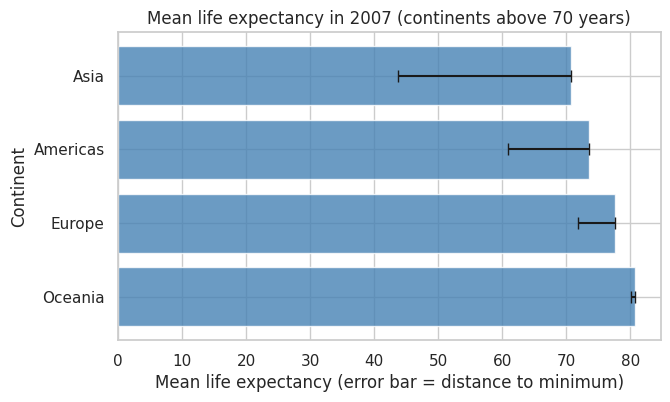

In [27]:
#@title Solution
summary = pd.read_sql("""
    SELECT c.continent,
           COUNT(DISTINCT m.country) AS n_countries,
           ROUND(AVG(m.lifeExp), 1) AS avg_life,
           ROUND(MIN(m.lifeExp), 1) AS min_life
    FROM measurements AS m
    INNER JOIN countries AS c ON m.country = c.country
    WHERE m.year = 2007
    GROUP BY c.continent
    HAVING AVG(m.lifeExp) > 70
    ORDER BY avg_life DESC
""", conn)

print(summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    summary["continent"],
    summary["avg_life"],
    xerr=[summary["avg_life"] - summary["min_life"], [0] * len(summary)],
    color="steelblue", capsize=4, alpha=0.8
)
ax.set_title("Mean life expectancy in 2007 (continents above 70 years)")
ax.set_xlabel("Mean life expectancy (error bar = distance to minimum)")
ax.set_ylabel("Continent")

## Module 10 complete

You have now used `df.query()` for readable Python-side filtering and SQL for querying a relational database with `SELECT`, `WHERE`, `GROUP BY`, `HAVING`, `JOIN`, and subqueries. The side-by-side translation table in notebook 10.6 captures the full vocabulary in one place. The SQL you practiced here transfers directly to PostgreSQL, MySQL, Google BigQuery, and every other major database system you will encounter in professional data work.

Module 11 introduces a third data structure: time-indexed sequences. The Gapminder data has a `year` column, but time series analysis treats the ordering and spacing of observations as load-bearing: gaps matter, direction matters, and adjacent values are related. Module 11 covers resampling (converting daily data to weekly or monthly summaries), rolling statistics (a moving average that tracks a shifting window), and seasonal patterns (grouping by month or day of week to find repeating structure). The dataset is a two-year daily record of bike rentals in Washington D.C., and the groupby and aggregation patterns from modules 09 and 10 carry over directly.